 A model for population growth in a collection of animals. Defined by the relation$$x_{n+1} = \mu x_n (1-x_n)$$
 where $x_{n}$ is the size of the population in generation $n$, and $\mu$ is a parameter related to the amount of food that is available

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# Function to calculate x_n+1 
def EulerLogisticMap (x_n, mu) : 
    return mu*x_n*(1-x_n) 


In [3]:
# function to create a list of x_n vs n 
def logisticmap( end_n, mu, start_x, deriv) : 
    
    n = np.arange(0, end_n) 
    x = np.zeros(len(n))
    x[0] = start_x
    
    for i in range (len(n)-1): 
        x[i+1] = deriv(x[i], mu) 
    
    return x, n
    

In [133]:
x06, n06=  logisticmap(50, 3.1, 0.6, EulerLogisticMap) 
x2, n2=  logisticmap(50, 2.0, 0.35, EulerLogisticMap) 
x38, n38=  logisticmap(50, 3.8, 0.35, EulerLogisticMap) 

<function matplotlib.pyplot.show(close=None, block=None)>

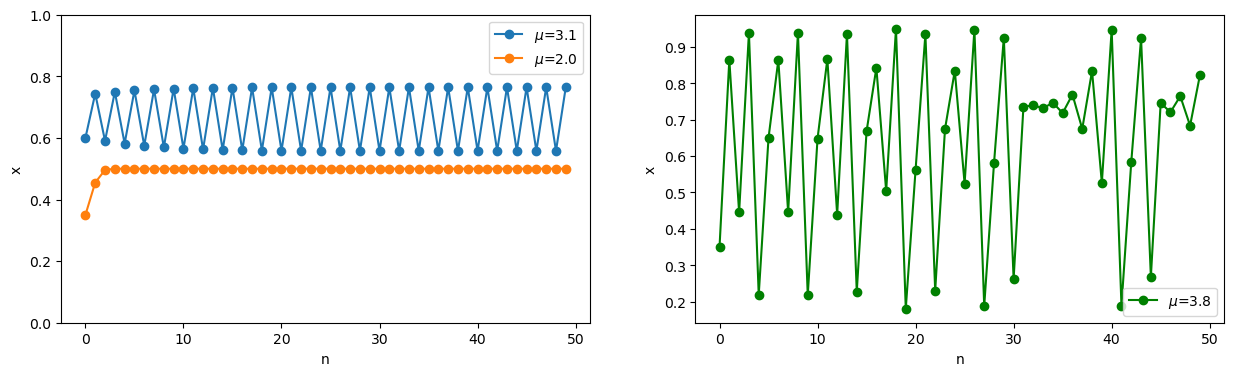

In [134]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 4))

ax1.plot(n06, x06, 'o',linestyle = "solid", label = r'$\mu$=3.1')
ax1.plot(n2, x2, 'o',linestyle = "solid", label = r'$\mu$=2.0') 
ax2.plot(n38, x38, 'o',linestyle = "solid", color = 'green',label = r'$\mu$=3.8') 
ax1.set_ylim(0,1)
ax1.set_ylim(0,1)
ax1.set(ylabel="x" , xlabel='n')
ax2.set(ylabel="x" , xlabel='n')
ax1.legend()
ax2.legend()
plt.show

## [Cobweb Plot](https://www.youtube.com/watch?v=_mWc6_u47lc&t=320s)  

In [219]:
# function to create a list of x_n vs x_n+1
def x_nplus1VSx_n (howmuch, mu, derivs, plus_howMuch) : 
    x_n = np.linspace(0,1,how_much) 
    x_nplus1 = np.zeros(len(x_n))
    x_nplus2 = np.zeros(len(x_n))
    
    for i in range(len(x_n)-1): 
        x_nplus1[i+1] = derivs(x_n[i], mu)  
        x_nplus2[i+1] = derivs(derivs(x_n[i], mu),mu) 
 

    if plus_howMuch == 1:
        return x_n, x_nplus1
    if plus_howMuch == 2:
        return x_n, x_nplus2

y = np.linspace(0,1,10)   # for line y=x

x_n15, x_nplus1_15 = x_nplus1VSx_n(500, 1.5, EulerLogisticMap,1) # logistic map with mu = 1.5
x_n33, x_nplus1_33 = x_nplus1VSx_n(500, 3.3,EulerLogisticMap, 1) # logistic map with mu = 3.3



In [214]:
def cobweb(num_iter, p_0, mu, function) : 
    point_list = [ ] # list of points for each iterations
    point_list.append((p_0, 0)) 

    for i in range(num_iter) : 
        m , n = point_list[-1] # m is point at x-axis, n is point at y-axis
        n = function(m, mu)
        point_list.append((m, n)) 
        m = n 
        point_list.append((m,n)) 
    point_array = np.array(point_list) 
    M, N = point_array.T

    return M,N
M15, N15 = cobweb(10, 0.5, 1.5, EulerLogisticMap) # cobweb for mu=1.5
M33, N33 = cobweb(10, 0.6, 3.3, EulerLogisticMap) # cobweb for mu=3.3


<function matplotlib.pyplot.show(close=None, block=None)>

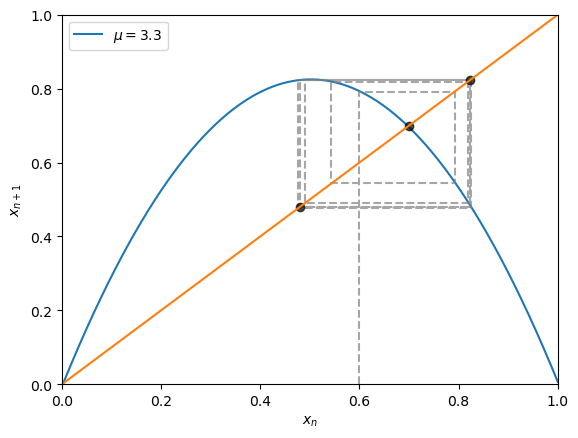

In [215]:

plt.plot(x_n33, x_nplus1_33, label = r'$\mu = 3.3$') 
plt.plot(M33, N33, linestyle = 'dashed', color = 'gray', alpha = 0.7) 
plt.plot(M33[-1], N33[-1], 'o', color = 'black', alpha = 0.7) 
plt.plot(M33[-3], N33[-3], 'o', color = 'black', alpha = 0.7) 
plt.plot(0.7, 0.7, 'o', color = 'black', alpha = 0.7) 
plt.plot(y, y) # y = x line 

plt.xlabel(r'$x_n$') 
plt.ylabel(r'$x_{n+1}$')
plt.xlim(0,1) 
plt.ylim(0,1)

plt.legend()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

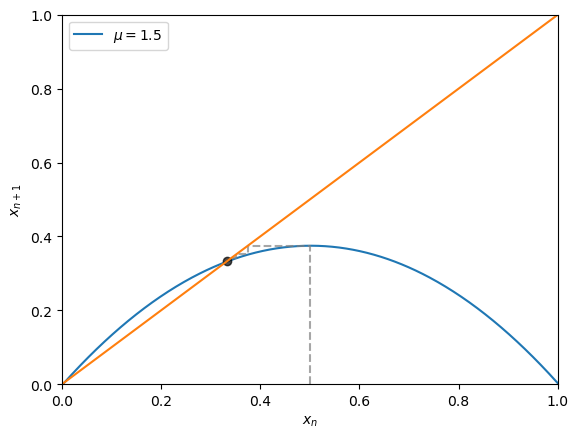

In [216]:
plt.plot(x_n15, x_nplus1_15, label = r'$\mu = 1.5$') 
plt.plot(M15, N15, linestyle = 'dashed', color = 'gray', alpha = 0.7) 
plt.plot(M15[-1], N15[-1], 'o', color = 'black', alpha = 0.7) 

plt.plot(y, y) # y = x line 

plt.xlabel(r'$x_n$') 
plt.ylabel(r'$x_{n+1}$')
plt.xlim(0,1) 
plt.ylim(0,1)

plt.legend()
plt.show


In [220]:
x_n33, x_nplus2_33 = x_nplus1VSx_n(500, 3.3,EulerLogisticMap, 2) # logistic map with mu = 3.3


<function matplotlib.pyplot.show(close=None, block=None)>

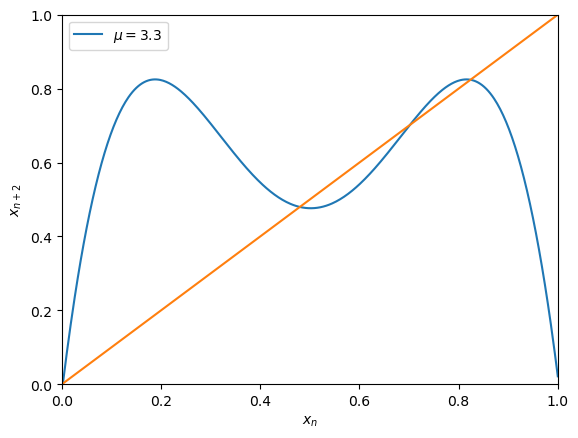

In [221]:
plt.plot(x_n33, x_nplus2_33, label = r'$\mu = 3.3$') 
plt.plot(y, y) # y = x line 

plt.xlabel(r'$x_n$') 
plt.ylabel(r'$x_{n+2}$')
plt.xlim(0,1) 
plt.ylim(0,1)

plt.legend()
plt.show